**PROJECT:Dynamic Sensor-Based Fault Detection & Drift Monitoring System**
   **PHASE 1:Problem Framing, Data Ingestion & Stream Simulation
      #Section 1: Local Environment Setup & Data Extraction
      Objective: Programmatically extract the downloaded academic dataset from the local environment download path and verify its structure inside             our working repository directory.

      Data Source: UCI Machine Learning Repository (AI4I 2020 Predictive Maintenance Dataset)
      Target Output: Extraction of `ai4i2020.csv` into the current working directory.

In [1]:
import os
import zipfile
#Defining Path
download_path = r"C:\Users\samma\Downloads\ai4i+2020+predictive+maintenance+dataset.zip"
current_project_dir = os.getcwd()
# Extracting the zip archive
if os.path.exists(download_path):
    with zipfile.ZipFile(download_path, 'r') as zip_ref:
        zip_ref.extractall(current_project_dir)
    print(f"Success! File extracted to: {current_project_dir}")
    print("Files in directory:", [f for f in os.listdir() if f.endswith('.csv')])
else:
    print(f" Error: Could not find the zip file at {download_path}")
    print("Please double check if the file extension is '.zip'.")

Success! File extracted to: C:\Sensor_Data
Files in directory: ['ai4i2020.csv', 'historical_baseline.csv', 'streaming_pool.csv']


Importing Necessary Libraries

In [2]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

 Reading Data From CSV File And Splitting It Into Two Separate Files

In [3]:
sensorData=pd.read_csv("ai4i2020.csv" , index_col='UDI')
pivot_index = 5000   #Splitting Index
historical_df = sensorData.iloc[:pivot_index]   #Saving the first half in a new dataframe
streaming_pool_df = sensorData.iloc[pivot_index:]  #Saving the other half into another new dataframe
historical_df.to_csv("historical_baseline.csv", index=False)  #Converting dataframe into a csv file
streaming_pool_df.to_csv("streaming_pool.csv", index=False)  #Converting dataframe into a csv file

Exploratory Data Anaalysis

In [4]:
sensorData.shape
sensorData.sample(10)
sensorData.describe()
sensorData.duplicated().sum()
sensorData.corr(numeric_only=True)
change_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF','Machine failure','Type']
for col in change_cols:  #Converting them to categorical types
    sensorData[col] = sensorData[col].astype('category')
sensorData.info() 

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 1 to 10000
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Product ID               10000 non-null  str     
 1   Type                     10000 non-null  category
 2   Air temperature [K]      10000 non-null  float64 
 3   Process temperature [K]  10000 non-null  float64 
 4   Rotational speed [rpm]   10000 non-null  int64   
 5   Torque [Nm]              10000 non-null  float64 
 6   Tool wear [min]          10000 non-null  int64   
 7   Machine failure          10000 non-null  category
 8   TWF                      10000 non-null  category
 9   HDF                      10000 non-null  category
 10  PWF                      10000 non-null  category
 11  OSF                      10000 non-null  category
 12  RNF                      10000 non-null  category
dtypes: category(7), float64(3), int64(2), str(1)
memory usage: 537.4 KB


TWF
0    4979
1      21
Name: count, dtype: int64
HDF
0    4885
1     115
Name: count, dtype: int64
PWF
0    4942
1      58
Name: count, dtype: int64
OSF
0    4949
1      51
Name: count, dtype: int64
RNF
0    4992
1       8
Name: count, dtype: int64
Machine failure
0    4765
1     235
Name: count, dtype: int64


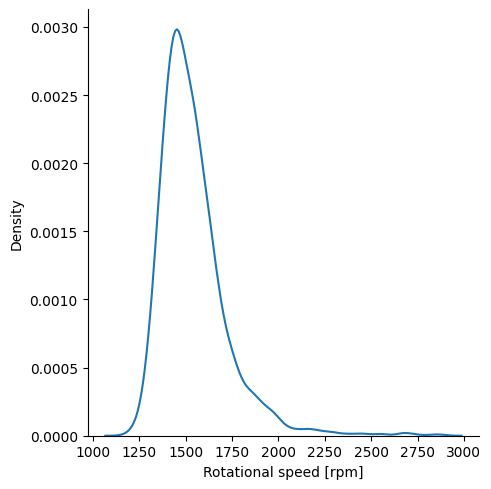

In [10]:
#Univariate Analysis

#Categorical Data
print(historical_df['TWF'].value_counts())
print(historical_df['HDF'].value_counts())
print(historical_df['PWF'].value_counts())
print(historical_df['OSF'].value_counts())
print(historical_df['RNF'].value_counts())
print(historical_df['Machine failure'].value_counts()) 

#Numerical Data
# 1. Boxplots
#sns.boxplot(data=historical_df, x='Air temperature [K]')
#sns.boxplot(data=historical_df, x='Process temperature [K]')
#sns.boxplot(data=historical_df, x='Torque [Nm]')
#sns.boxplot(data=historical_df, x='Tool wear [min]')
# 2. KDE Distribution Plots
#sns.displot(data=historical_df, x='Air temperature [K]', kind='kde')
#sns.displot(data=historical_df, x='Process temperature [K]', kind='kde')
#sns.displot(data=historical_df, x='Torque [Nm]', kind='kde')
#sns.displot(data=historical_df, x='Tool wear [min]', kind='kde')
#sns.displot(data=historical_df, x='Rotational speed [rpm]', kind='kde')

<Axes: xlabel='Type', ylabel='Torque [Nm]'>

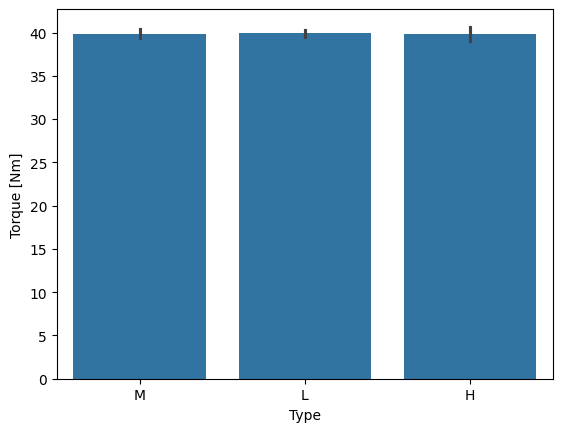

In [13]:
#Bivariate Analysis

#Scatter Plots
#sns.scatterplot(data=historical_df, x='Air temperature [K]', y='Process temperature [K]')
#sns.scatterplot(data=historical_df, x='Rotational speed [rpm]', y='Torque [Nm]')
#Bar Plots
#sns.barplot(data=historical_df, x='Type', y='Torque [Nm]')
#sns.barplot(data=historical_df, x='Type', y='Rotational speed [rpm]')
#sns.barplot(data=historical_df, x='Type', y='Tool wear [min]')
#Box Plots
#sns.boxplot(data=historical_df[historical_df['TWF'] == 1],x='Tool wear [min]')
#sns.boxplot(data=historical_df, x='TWF', y='Tool wear [min]')
#sns.boxplot(data=historical_df[historical_df['PWF'] == 1],x='Torque [Nm]') 
#sns.boxplot(data=historical_df, x='PWF', y='Torque [Nm]')
#sns.boxplot(data=historical_df[historical_df['HDF'] == 1],x='Process temperature [K]')
#sns.boxplot(data=historical_df, x='HDF', y='Process temperature [K]')
#Crosstabs
#type_vs_twf = pd.crosstab(historical_df['Type'], historical_df['TWF'],normalize='index') *100
#print(type_vs_twf)
#type_vs_twf.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#2b7bba', '#e05a47'])
#type_vs_osf = pd.crosstab(historical_df['Type'], historical_df['OSF'],normalize='index') *100
#print(type_vs_osf)
#type_vs_osf.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#2b7bba', '#e05a47'])
#type_vs_hdf = pd.crosstab(historical_df['Type'], historical_df['HDF'],normalize='index') *100
#print(type_vs_hdf)
#type_vs_hdf.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#2b7bba', '#e05a47'])
#type_vs_pwf = pd.crosstab(historical_df['Type'], historical_df['PWF'],normalize='index') *100
#print(type_vs_pwf)
#type_vs_pwf.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#2b7bba', '#e05a47'])
#type_vs_rnf =historical_df.groupby('Type')['RNF'].mean()*100  #this and above are both same commands just the difference is that above shows all three types and working and failure for each type but this shows three type and only failure for each type as when mean is used mean of 0,1 is 1. 
#print(type_vs_rnf)
#type_vs_rnf.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#2b7bba', '#e05a47'])

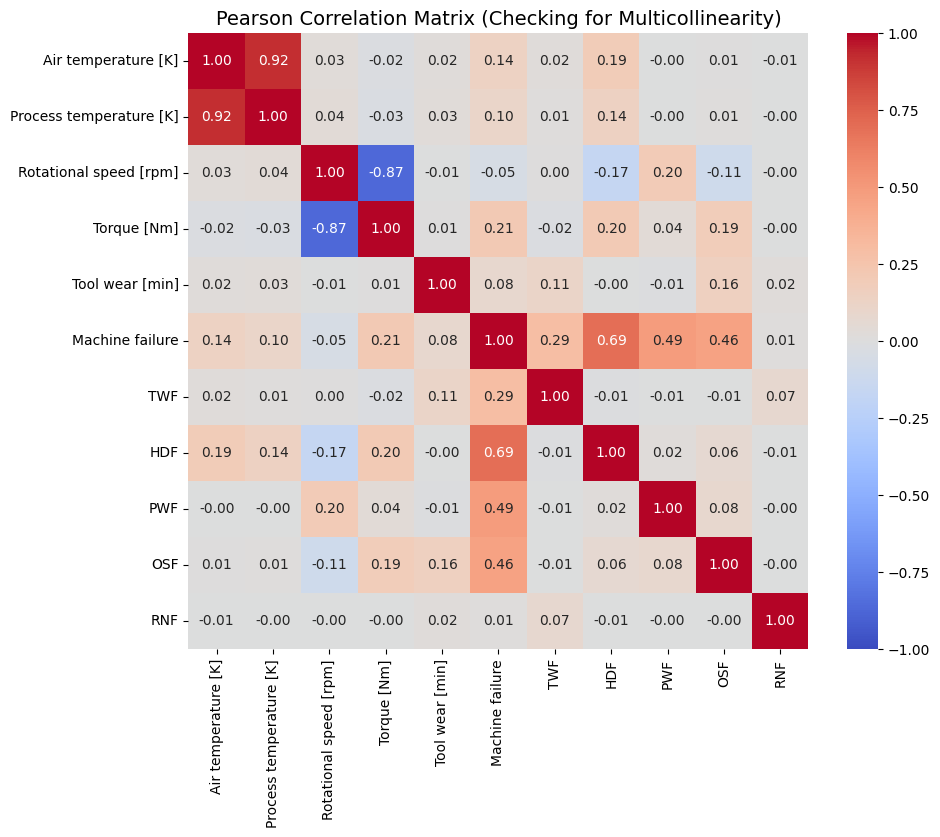

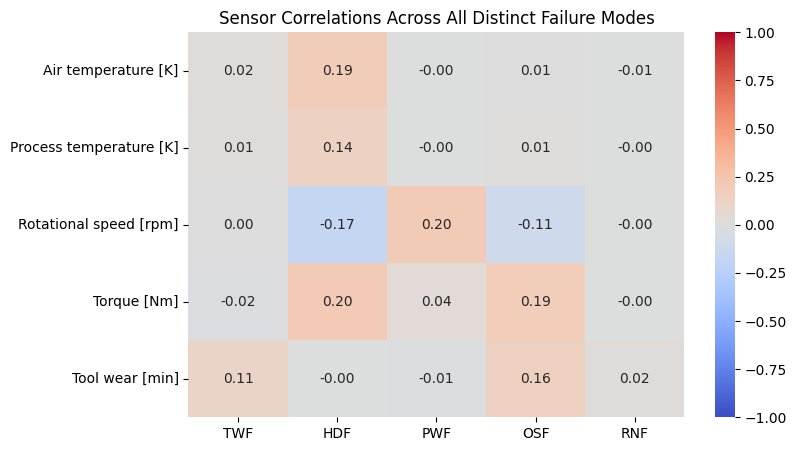

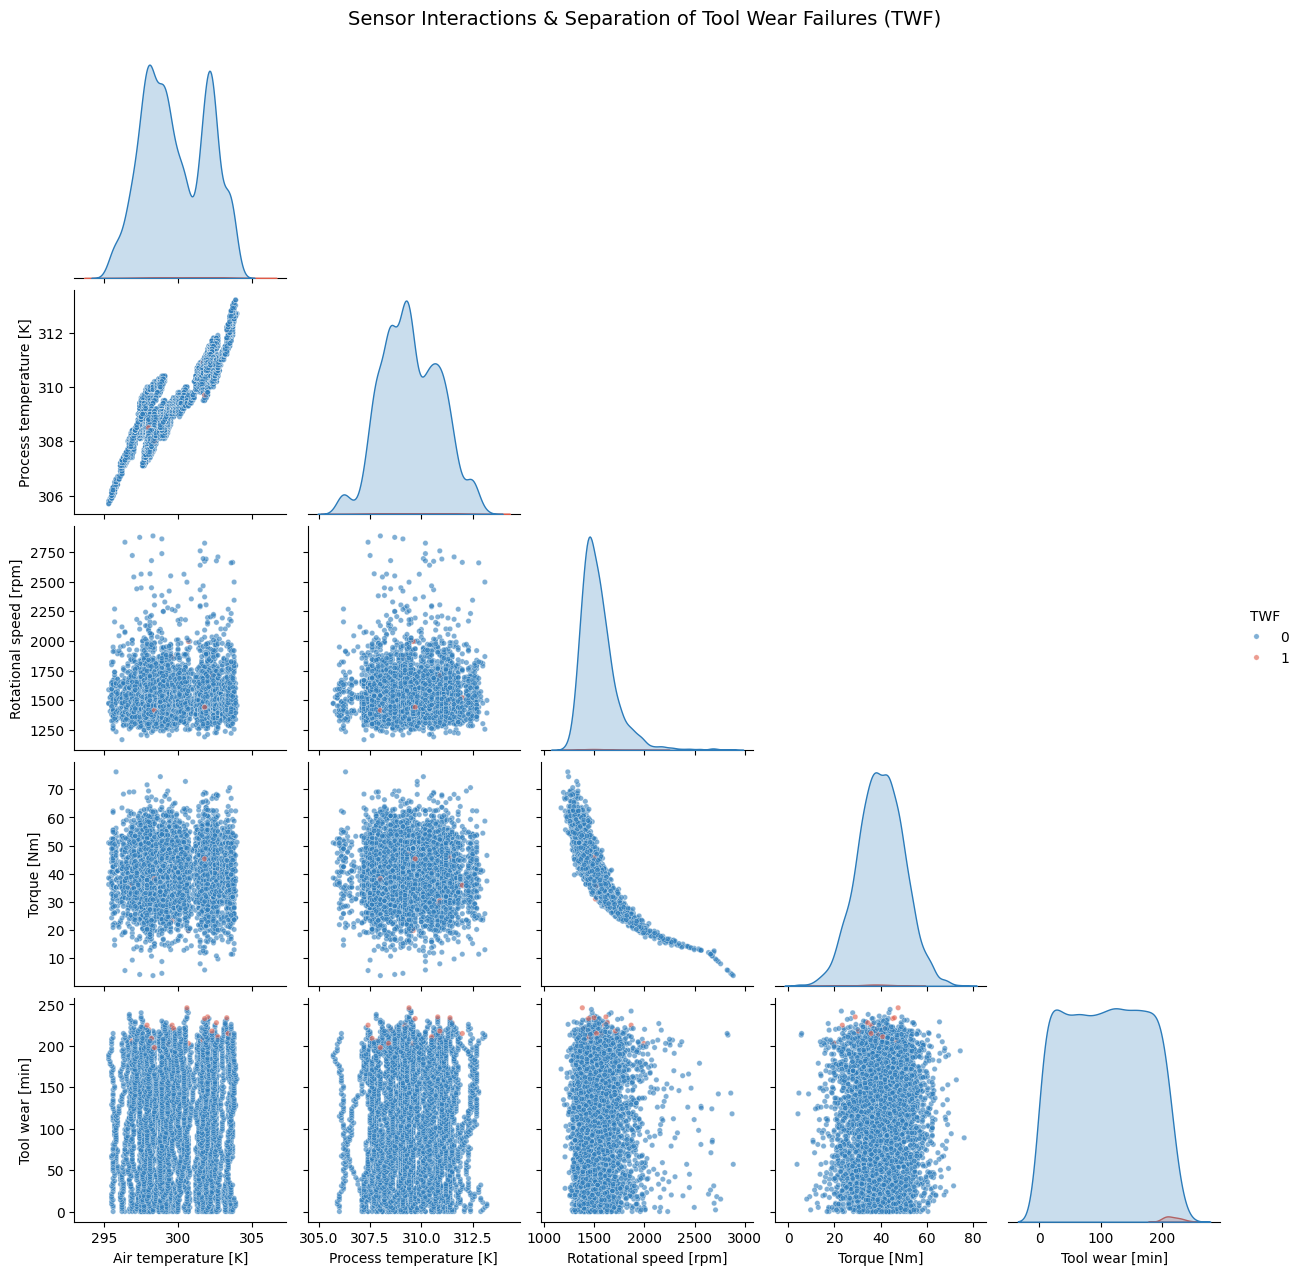

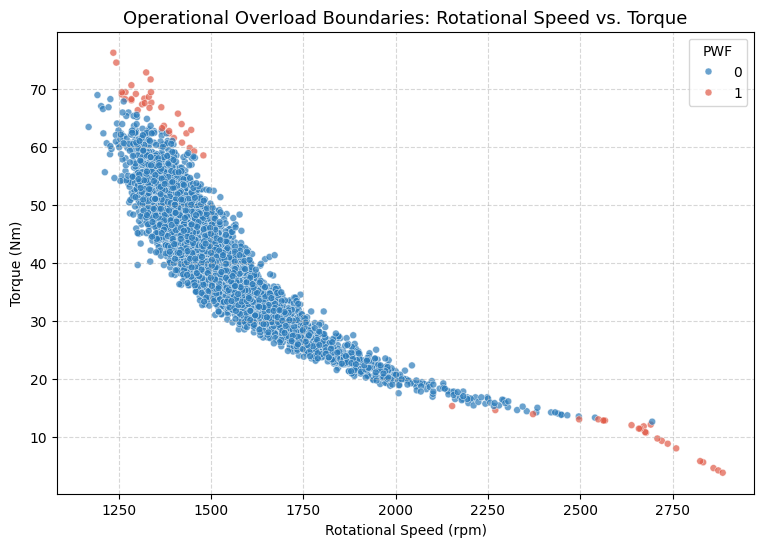

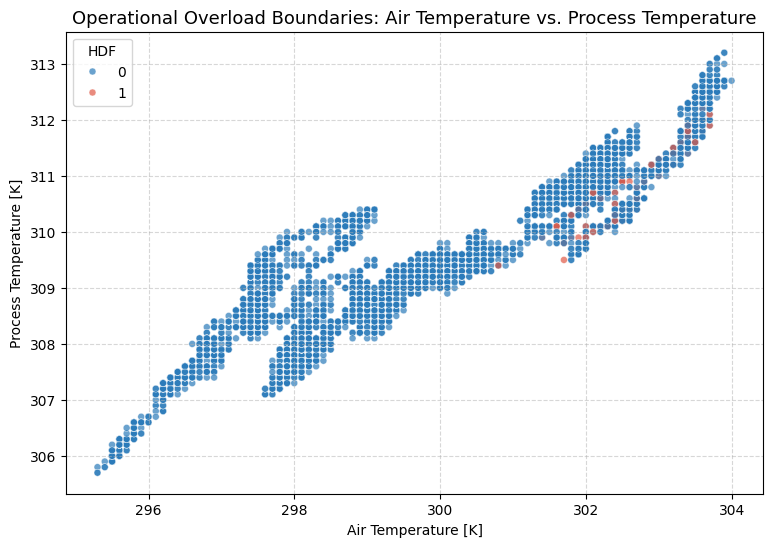

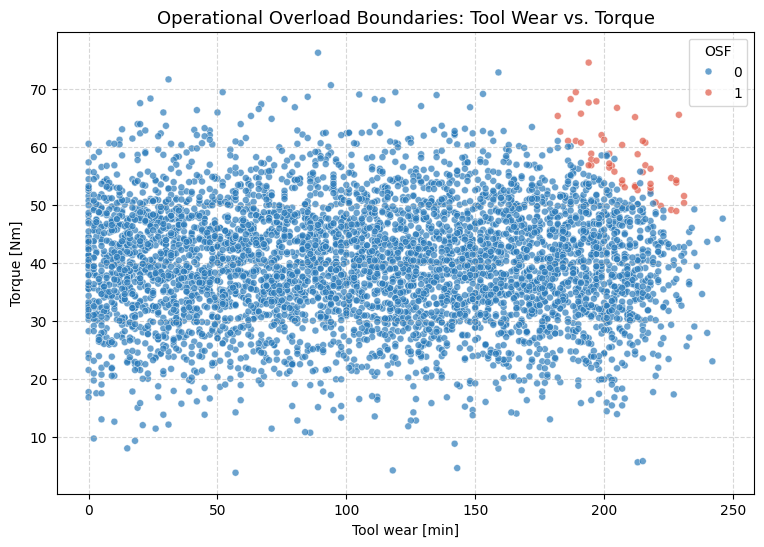

In [7]:
#Multivariate Analysis

#heatmap
#1
plt.figure(figsize=(10, 8))
numeric_df = historical_df.select_dtypes(include=['number'])  #Isolating the numerical column
correlation_matrix = numeric_df.corr(method='pearson')   #Computing correlation 
sns.heatmap(data=correlation_matrix, annot=True, fmt=".2f",cmap='coolwarm',vmin=-1, vmax=1)
plt.title("Pearson Correlation Matrix (Checking for Multicollinearity)", fontsize=14)
#2
sensor_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
cross_corr = historical_df[sensor_cols + failure_cols].corr().loc[sensor_cols, failure_cols]
plt.figure(figsize=(8, 5))
sns.heatmap(cross_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Sensor Correlations Across All Distinct Failure Modes")
plt.show()
#pairplot
cols_to_plot = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF']
eda_subset = historical_df[cols_to_plot]
sns.pairplot(data=eda_subset,hue='TWF',palette={0: '#2b7bba', 1: '#e05a47'},diag_kind='kde',plot_kws={'alpha': 0.6, 's': 15},corner=True)
plt.suptitle("Sensor Interactions & Separation of Tool Wear Failures (TWF)", y=1.02, fontsize=14)
plt.show()
#3 Variable scatter plot
#a
plt.figure(figsize=(9, 6))
sns.scatterplot(data=historical_df,x='Rotational speed [rpm]',y='Torque [Nm]',hue='PWF',palette={0: '#2b7bba', 1: '#e05a47'}, alpha=0.7,s=25)
plt.title("Operational Overload Boundaries: Rotational Speed vs. Torque", fontsize=13)
plt.xlabel("Rotational Speed (rpm)")
plt.ylabel("Torque (Nm)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
#b
plt.figure(figsize=(9, 6))
sns.scatterplot(data=historical_df,x='Air temperature [K]',y='Process temperature [K]',hue='HDF',palette={0: '#2b7bba', 1: '#e05a47'}, alpha=0.7,s=25)
plt.title("Operational Overload Boundaries: Air Temperature vs. Process Temperature", fontsize=13)
plt.xlabel("Air Temperature [K]")
plt.ylabel("Process Temperature [K]")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
#c
plt.figure(figsize=(9, 6))
sns.scatterplot(data=historical_df,x='Tool wear [min]',y='Torque [Nm]',hue='OSF',palette={0: '#2b7bba', 1: '#e05a47'}, alpha=0.7,s=25)
plt.title("Operational Overload Boundaries: Tool Wear vs. Torque", fontsize=13)
plt.xlabel("Tool wear [min]")
plt.ylabel("Torque [Nm]")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()